# TGAT — Threshold Tuning & Evaluation

Looks up the best run from MLflow experiment `tgat-sampler` by `val_auc`, loads the saved `.pth` from `saved_models/`, tunes the decision threshold on the **val set** by maximising MCC, then reports all metrics on the **test set**.

## Imports & setup

In [2]:
import os
import sys
import warnings
import logging

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    recall_score,
    precision_score,
    roc_curve,
    precision_recall_curve,
)
from utils import recall_at_top_n_percent

from models import THEGCNModel, THEGCNSamplerModel

import mlflow
import matplotlib.pyplot as plt

# Enable faulthandler so segfaults produce a Python traceback
import faulthandler
faulthandler.enable()

from models import TGATModel, TGATSamplerModel
from utils import *
from namespaces import DA
from dgraphfin import load_dgraphfin_temporal
# from sampler import TemporalSampler, load_sampler_data
from sampler_core import ParallelSampler, TemporalGraphBlock

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARN)

In [3]:
os.chdir('/home/mai/notebooks/final_thesis/')
sys.path.insert(0, './src')
# os.makedirs('./eval_plots', exist_ok=True)

## Find best run in MLflow

In [4]:
# Search MLflow for the best TGAT run by val_auc
experiment_name = 'tgat-sampler'
metric_name     = 'val_auc'

exp  = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[f"metrics.{metric_name} DESC"],
    max_results=1,
)

best_run    = runs.iloc[0]
best_run_id = best_run["run_id"]

prefix = best_run["params.prefix"]
data   = best_run["params.data"]

print("Best run ID  :", best_run_id)
print(f"Best {metric_name} :", best_run[f"metrics.{metric_name}"])

Best run ID  : 784e4393ec1a453f895f0f35a0491faf
Best val_auc : 0.7757475241084051


## Recover model path from logged params

In [5]:
model_path  = f'./saved_models/{prefix}-tgat-with-sampler-node-{data}.pth'
print("Model path  :", model_path)

Model path  : ./saved_models/run1-tgat-with-sampler-node-DGraphFin.pth


In [6]:
# ── Architecture config — must match the values used during training ──────────
NODE_DIM        = int(best_run['params.node_dim'])
TIME_DIM        = int(best_run['params.time_dim'])
NUM_LAYER       = int(best_run['params.n_layer'])
NUM_HEAD        = int(best_run['params.n_head'])

NUM_NEIGHBOR    = int(best_run['params.n_neighbor'])
STRATEGY        = best_run['params.strategy']
PROP_TIME       = best_run['params.prop_time'] == 'True'
HISTORY         = int(best_run['params.history'])
DURATION        = float(best_run['params.duration'])
BATCH_SIZE      = int(best_run['params.bs'])

NUM_WORKERS     = int(best_run['params.num_workers'])
NUM_THREADS     = int(best_run['params.num_threads'])

N_THRESHOLD     = 500
DROP_OUT        = float(best_run['params.drop_out'])
GPU             = int(best_run['params.gpu'])
FOLD            = 0
DATA_DIR        = './datasets'
SAMPLE_DIR      = './processed_data/tgl'

# Load data

In [7]:
(graph, train_idx, val_idx, test_idx,
 train_labels_np, node_feat_dim) = load_dgraphfin_temporal(
    data_dir      = DATA_DIR,
    fold          = FOLD,
    to_undirected = False,
)

print(f'Graph : {graph.num_nodes:,} nodes | {graph.num_edges:,} edges')
print(f'Val   : {len(val_idx):,} nodes')
print(f'Test  : {len(test_idx):,} nodes')

Graph : 3,700,550 nodes | 4,300,999 edges
Val   : 183,862 nodes
Test  : 183,840 nodes


In [8]:
# Full node feature matrix and labels on CPU (indexed by global node id)
x_all         = graph.x                # [N, node_feat_dim]
y_all         = graph.y                # [N]
node_time_all = graph.node_time        # [N]  float

In [9]:
# Load CSC sampler data and build TemporalSampler
g, df = load_graph(SAMPLE_DIR)
assert len(g['indptr']) == x_all.shape[0] + 1

In [10]:
device = torch.device(f'cuda:{GPU}' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

x_all         = x_all.to(device)
node_time_all = node_time_all.to(device)
y_all         = y_all.to(device)

Device: cuda:0


# Sampler

In [11]:
# num_neighbors per layer: outer → inner, linearly decreasing
if NUM_LAYER == 0:
    num_neighbors = []      # TMP only
elif NUM_LAYER == 1:
    num_neighbors = [NUM_NEIGHBOR]
elif NUM_LAYER == 2:
    num_neighbors = [NUM_NEIGHBOR, 5]
else:
    step = max(1, (NUM_NEIGHBOR - 5) // (NUM_LAYER - 1))
    num_neighbors = [max(5, NUM_NEIGHBOR - i * step) for i in range(NUM_LAYER)]

sampler = ParallelSampler(
    g['indptr'], 
    g['indices'], 
    g['eid'], 
    g['ts'].astype(np.float32),
    NUM_THREADS, 
    NUM_WORKERS,                               # num_workers
    NUM_LAYER, 
    num_neighbors,
    STRATEGY=='recent', 
    PROP_TIME,
    HISTORY, 
    float(DURATION)
)

# Load saved weights

In [12]:
gnn = TGATSamplerModel(
    in_channels     = node_feat_dim,
    hidden_channels = NODE_DIM,
    n_layers        = NUM_LAYER,
    time_dim        = TIME_DIM,
    dropout         = DROP_OUT,
    n_head          = NUM_HEAD,
).to(device)

gnn.load_state_dict(torch.load(model_path, map_location=device))
gnn.eval()
print(f'Loaded  : {model_path}')
print(f'Params  : {sum(p.numel() for p in gnn.parameters()):,}')

Loaded  : ./saved_models/run1-tgat-with-sampler-node-DGraphFin.pth
Params  : 193,153


## Inference helper

In [13]:
@torch.no_grad()
def get_scores(split_idx):
    all_scores, all_labels = [], []
    # iterate in batches
    idx_array = split_idx.cpu().numpy()
    for start in range(0, len(idx_array), BATCH_SIZE * 2):
        batch_idx = idx_array[start : start + BATCH_SIZE * 2]
        root_nodes = batch_idx.astype(np.int32)
        ts         = node_time_all[batch_idx].cpu().numpy().astype(np.float32)
        
        sampler.sample(root_nodes, ts)
        ret        = sampler.get_ret()
        mfgs       = to_dgl_blocks(ret, hist=HISTORY, reverse=False, cuda=(device.type != 'cpu'))
        batch_inputs = to_pyg_inputs(mfgs, device=device)

        n_seeds = batch_inputs[-1][0]['size'][1]   # num_dst_nodes of innermost block
        labels  = y_all[batch_inputs[-1][0]['node_ids'][:n_seeds]]
 
        logits = gnn(
            x_all        = x_all,
            batch_inputs = batch_inputs,
            batch_size   = n_seeds,
        )
        all_scores.append(logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

## Cutoff selection — maximise MCC on val set

Best cutoff : 0.9780
Val MCC     : 0.1129


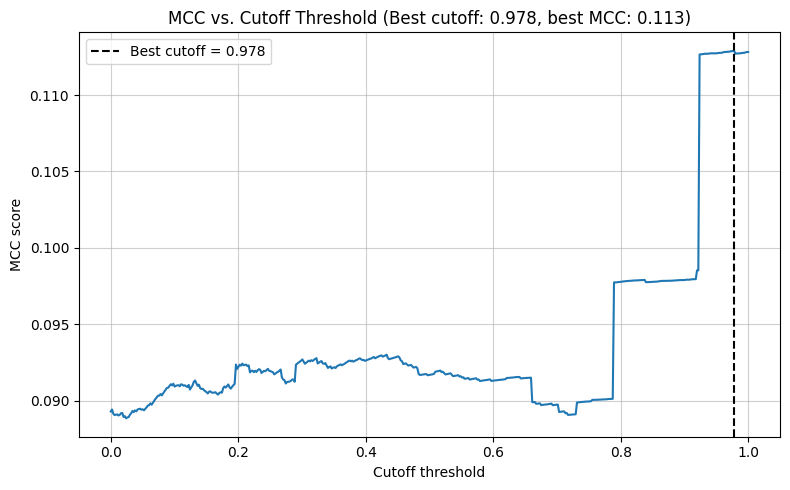

In [14]:
# ── Cutoff selection to maximise MCC (val set) ───────────────────────────────
y_prob_val, y_true_val = get_scores(val_idx)

thresholds = np.linspace(0, 1, N_THRESHOLD)
mcc_scores = []
for t in thresholds:
    y_pred = (y_prob_val >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_true_val, y_pred))

best_idx       = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc       = mcc_scores[best_idx]

print(f'Best cutoff : {best_threshold:.4f}')
print(f'Val MCC     : {best_mcc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k',
            label=f'Best cutoff = {best_threshold:.3f}')
plt.title(f'MCC vs. Cutoff Threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})')
plt.xlabel('Cutoff threshold')
plt.ylabel('MCC score')
plt.legend()
plt.grid(True, axis='both', alpha=0.6)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-mcc-threshold.png', dpi=150)
plt.show()

## Test-set evaluation

In [15]:
# ── Apply best threshold to test set ─────────────────────────────────────────
y_prob, y_true = get_scores(test_idx)
y_pred = (y_prob >= best_threshold).astype(int)

auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
f1  = f1_score(y_true, y_pred,  zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
rc  = recall_score(y_true, y_pred, zero_division=0)
pr  = precision_score(y_true, y_pred, zero_division=0)
rc_at_1 = recall_at_top_n_percent(y_true, y_prob, n_percent=1)
rc_at_10 = recall_at_top_n_percent(y_true, y_prob, n_percent=10)

print(f'AUC       : {auc:.4f}')
print(f'AP        : {ap:.4f}')
print(f'F1        : {f1:.4f}')
print(f'MCC       : {mcc:.4f}')
print(f'Recall    : {rc:.4f}')
print(f'Precision : {pr:.4f}')
print(f'Recall at 1% : {rc_at_1:.4f}')
print(f'Recall at 10% : {rc_at_10:.4f}')

AUC       : 0.7792
AP        : 0.1715
F1        : 0.1105
MCC       : 0.1117
Recall    : 0.2438
Precision : 0.0714
Recall at 1% : 0.1608
Recall at 10% : 0.3482


## ROC Curve

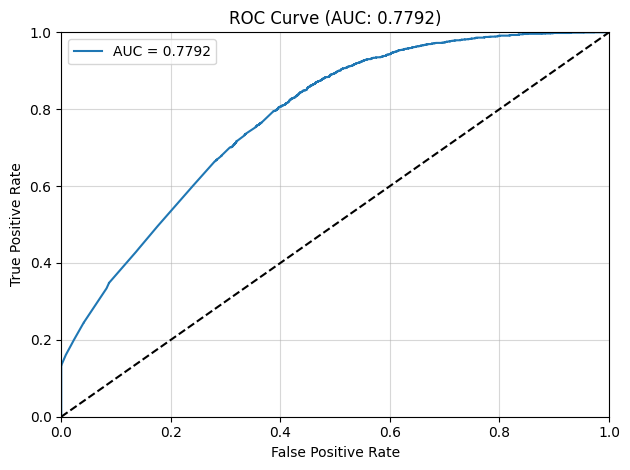

In [16]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], ls='--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC: {auc:.4f})')
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-roc.png', dpi=150)
plt.show()

## Precision-Recall Curve

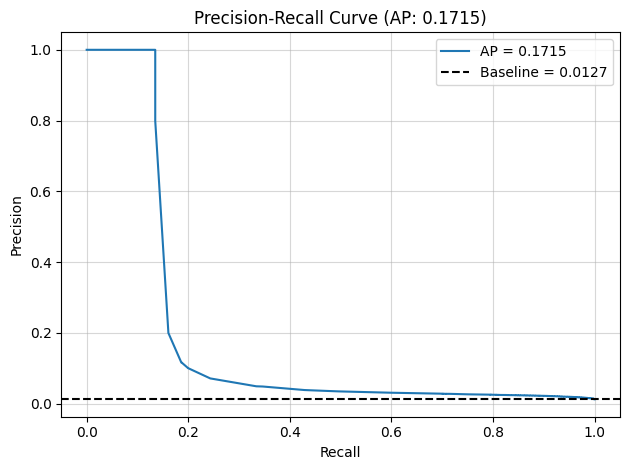

In [17]:
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
baseline = np.mean(y_true)

plt.figure()
plt.plot(rec_curve, prec_curve, label=f'AP = {ap:.4f}')
plt.axhline(baseline, linestyle='--', color='k', label=f'Baseline = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP: {ap:.4f})')
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-pr.png', dpi=150)
plt.show()

## Gain & Lift Charts

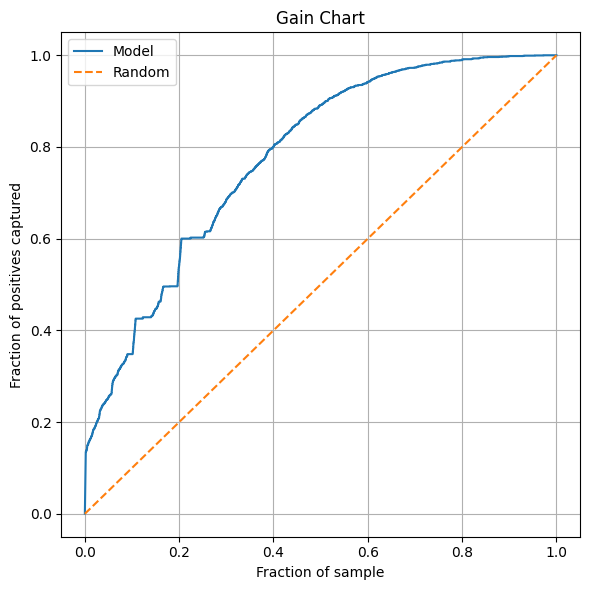

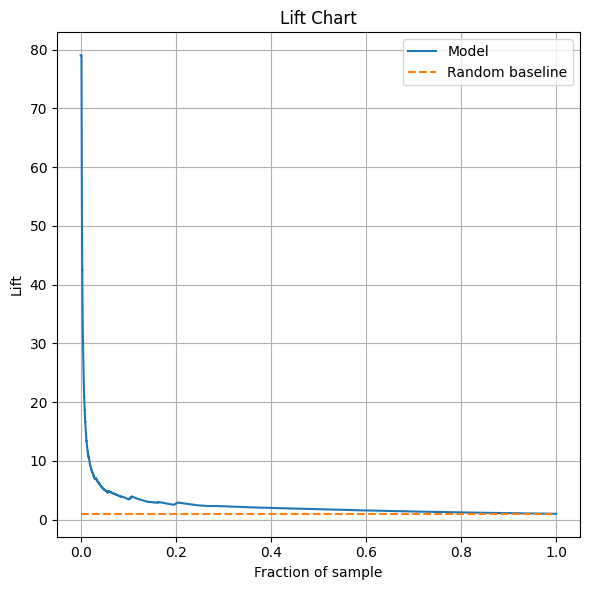

In [18]:
gl = pd.DataFrame({'y_test': y_true, 'y_prob': y_prob})
gl = gl.sort_values('y_prob', ascending=False).reset_index(drop=True)
gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain']          = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac']  = np.arange(1, len(gl) + 1) / len(gl)

plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['gain'], label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('Fraction of sample')
plt.ylabel('Fraction of positives captured')
plt.title('Gain Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-gain.png', dpi=150)
plt.show()

gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['lift'], label='Model')
plt.plot([0, 1], [1, 1], linestyle='--', label='Random baseline')
plt.xlabel('Fraction of sample')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-lift.png', dpi=150)
plt.show()

## KS Plot

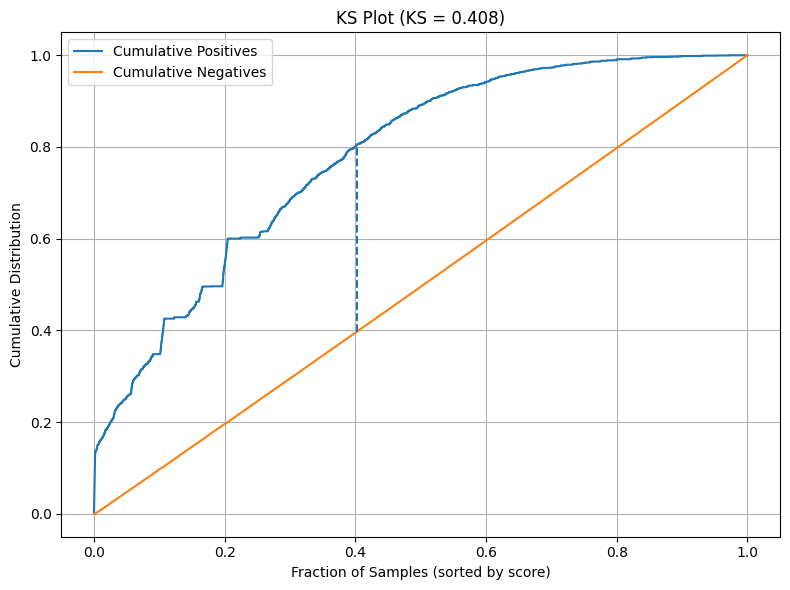

KS statistic : 0.4084
Plots saved  : ./eval_plots/


In [19]:
gl['neg']           = 1 - gl['y_test']
gl['cum_negatives'] = gl['neg'].cumsum()
gl['cum_pos_rate']  = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate']  = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]
gl['ks']            = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx   = gl['ks'].abs().idxmax()

plt.figure(figsize=(8, 6))
plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')
plt.title(f'KS Plot (KS = {ks_value:.3f})')
plt.xlabel('Fraction of Samples (sorted by score)')
plt.ylabel('Cumulative Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-ks.png', dpi=150)
plt.show()

print(f'KS statistic : {ks_value:.4f}')
print(f'Plots saved  : ./eval_plots/')